In [5]:
#### IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
### LOAD THE DATASETS
orders = pd.read_csv(
    "../../data/raw/olist_orders_dataset.csv"
)

order_items = pd.read_csv(
    "../../data/raw/olist_order_items_dataset.csv"
)

customers = pd.read_csv(
    "../../data/raw/olist_customers_dataset.csv"
)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Customers:", customers.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Customers: (99441, 5)


In [7]:
 # ---------------------------------------------------------
# 2. Connect customers to orders
# ---------------------------------------------------------

customer_orders = customers[
    ['customer_id', 'customer_unique_id']
].merge(
    orders[
        ['order_id', 'customer_id']
    ],
    on='customer_id',
    how='inner'
)

customer_orders.head()

,customer_id,customer_unique_id,order_id
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,29150127e6685892b6eab3eec79f59c7
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,b2059ed67ce144a36e2aa97d2c9e9ad2
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,951670f92359f4fe4a63112aa7306eba
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,6b7d50bd145f6fc7f33cebabd7e49d0f


In [8]:
# ---------------------------------------------------------
# 3. Connect orders to order items
# ---------------------------------------------------------

customer_data = customer_orders.merge(
    order_items[
        ['order_id', 'order_item_id', 'price']
    ],
    on='order_id',
    how='inner'
)

customer_data.head()

,customer_id,customer_unique_id,order_id,order_item_id,price
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1,1,124.99
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,29150127e6685892b6eab3eec79f59c7,1,289.00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,b2059ed67ce144a36e2aa97d2c9e9ad2,1,139.94
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,951670f92359f4fe4a63112aa7306eba,1,149.94
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,6b7d50bd145f6fc7f33cebabd7e49d0f,1,230.00


In [13]:
# ---------------------------------------------------------
# 4. Create customer-level metrics
# ---------------------------------------------------------

customer_summary = (
    customer_data
    .groupby('customer_unique_id')
    .agg(
        TotalOrders=('order_id', 'nunique'),
        TotalItems=('order_item_id', 'count'),
        TotalRevenue=('price', 'sum')
    )
    .reset_index()
)

customer_summary['AverageOrderValue'] = (
    customer_summary['TotalRevenue']
    / customer_summary['TotalOrders']
)

customer_summary['TotalRevenue'] = (
    customer_summary['TotalRevenue'].round(2)
)

customer_summary['AverageOrderValue'] = (
    customer_summary['AverageOrderValue'].round(2)
)

customer_summary.head(10)

,customer_unique_id,TotalOrders,TotalItems,TotalRevenue,AverageOrderValue
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,129.90,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,18.90,18.90
2,0000f46a3911fa3c0805444483337064,1,1,69.00,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,25.99,25.99
4,0004aac84e0df4da2b147fca70cf8255,1,1,180.00,180.00
5,0004bd2a26a76fe21f786e4fbd80607f,1,1,154.00,154.00
6,00050ab1314c0e55a6ca13cf7181fecf,1,1,27.99,27.99
7,00053a61a98854899e70ed204dd4bafe,1,2,382.00,382.00
8,0005e1862207bf6ccc02e4228effd9a0,1,1,135.00,135.00
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1,1,104.90,104.90


In [14]:
# ---------------------------------------------------------
# 5. Customer KPIs
# ---------------------------------------------------------

total_customers = len(customer_summary)

one_time_customers = (
    customer_summary['TotalOrders']
    .eq(1)
    .sum()
)

repeat_customers = (
    customer_summary['TotalOrders']
    .gt(1)
    .sum()
)

repeat_customer_percentage = (
    repeat_customers * 100
    / total_customers
)

print("Total Customers:", total_customers)
print("One-Time Customers:", one_time_customers)
print("Repeat Customers:", repeat_customers)
print(
    "Repeat Customer Percentage:",
    round(repeat_customer_percentage, 2),
    "%"
)

Total Customers: 95420
One-Time Customers: 92507
Repeat Customers: 2913
Repeat Customer Percentage: 3.05 %


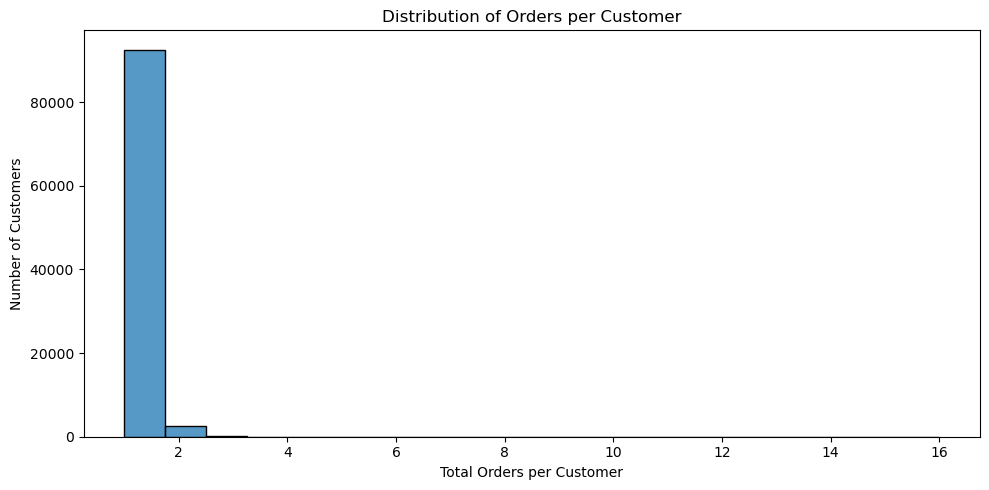

In [11]:
# ---------------------------------------------------------
# 6. Distribution of Orders per Customer
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    data=customer_summary,
    x='TotalOrders',
    bins=20
)

plt.title('Distribution of Orders per Customer')
plt.xlabel('Total Orders per Customer')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

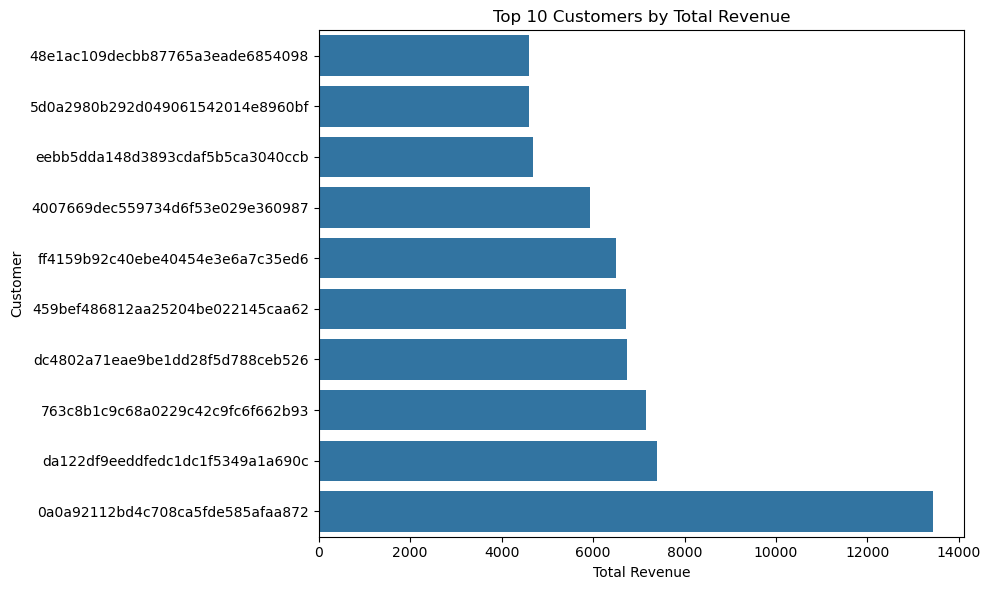

In [16]:
# ---------------------------------------------------------
# 7. Top 10 Customers by Revenue
# ---------------------------------------------------------

top10_customers = (
    customer_summary
    .nlargest(10, 'TotalRevenue')
    .sort_values('TotalRevenue')
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10_customers,
    x='TotalRevenue',
    y='customer_unique_id'
)

plt.title('Top 10 Customers by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Customer')

plt.tight_layout()
plt.show()

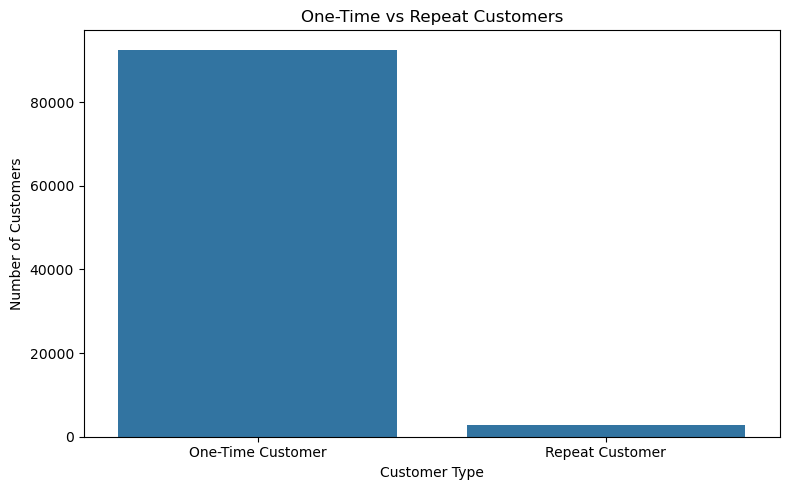

In [17]:
# ---------------------------------------------------------
# 8. One-Time vs Repeat Customers
# ---------------------------------------------------------

customer_summary['CustomerType'] = np.where(
    customer_summary['TotalOrders'] > 1,
    'Repeat Customer',
    'One-Time Customer'
)

customer_type_counts = (
    customer_summary['CustomerType']
    .value_counts()
    .reset_index()
)

customer_type_counts.columns = [
    'CustomerType',
    'TotalCustomers'
]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=customer_type_counts,
    x='CustomerType',
    y='TotalCustomers'
)

plt.title('One-Time vs Repeat Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [15]:
# ---------------------------------------------------------
# 9. Top customers table
# ---------------------------------------------------------

customer_summary.sort_values(
    'TotalRevenue',
    ascending=False
).head(10)

,customer_unique_id,TotalOrders,TotalItems,TotalRevenue,AverageOrderValue
3799,0a0a92112bd4c708ca5fde585afaa872,1,8,13440.0,13440.0
81388,da122df9eeddfedc1dc1f5349a1a690c,2,2,7388.0,3694.0
44139,763c8b1c9c68a0229c42c9fc6f662b93,1,4,7160.0,7160.0
82230,dc4802a71eae9be1dd28f5d788ceb526,1,1,6735.0,6735.0
26015,459bef486812aa25204be022145caa62,1,1,6729.0,6729.0
95131,ff4159b92c40ebe40454e3e6a7c35ed6,1,1,6499.0,6499.0
23947,4007669dec559734d6f53e029e360987,1,6,5934.6,5934.6
89056,eebb5dda148d3893cdaf5b5ca3040ccb,1,1,4690.0,4690.0
34820,5d0a2980b292d049061542014e8960bf,1,2,4599.9,4599.9
27242,48e1ac109decbb87765a3eade6854098,1,1,4590.0,4590.0


In [16]:
# =========================================================
# P15: RFM Customer Analysis
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Connect customers to orders
# ---------------------------------------------------------

customer_orders = customers[
    ['customer_id', 'customer_unique_id']
].merge(
    orders[
        ['order_id', 'customer_id', 'order_purchase_timestamp']
    ],
    on='customer_id',
    how='inner'
)

customer_orders.head()

,customer_id,customer_unique_id,order_id,order_purchase_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1,2017-05-16 15:05:35
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,29150127e6685892b6eab3eec79f59c7,2018-01-12 20:48:24
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,b2059ed67ce144a36e2aa97d2c9e9ad2,2018-05-19 16:07:45
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,951670f92359f4fe4a63112aa7306eba,2018-03-13 16:06:38
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,6b7d50bd145f6fc7f33cebabd7e49d0f,2018-07-29 09:51:30


In [17]:
# ---------------------------------------------------------
# 2. Convert purchase date
# ---------------------------------------------------------

customer_orders['order_purchase_timestamp'] = pd.to_datetime(
    customer_orders['order_purchase_timestamp'],
    errors='coerce'
)

customer_orders.head()

,customer_id,customer_unique_id,order_id,order_purchase_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1,2017-05-16 15:05:35
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,29150127e6685892b6eab3eec79f59c7,2018-01-12 20:48:24
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,b2059ed67ce144a36e2aa97d2c9e9ad2,2018-05-19 16:07:45
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,951670f92359f4fe4a63112aa7306eba,2018-03-13 16:06:38
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,6b7d50bd145f6fc7f33cebabd7e49d0f,2018-07-29 09:51:30


In [18]:
# ---------------------------------------------------------
# 3. Connect orders to order items
# ---------------------------------------------------------

customer_data = customer_orders.merge(
    order_items[
        ['order_id', 'order_item_id', 'price']
    ],
    on='order_id',
    how='inner'
)

customer_data.head()

,customer_id,customer_unique_id,order_id,order_purchase_timestamp,order_item_id,price
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1,2017-05-16 15:05:35,1,124.99
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,29150127e6685892b6eab3eec79f59c7,2018-01-12 20:48:24,1,289.00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,b2059ed67ce144a36e2aa97d2c9e9ad2,2018-05-19 16:07:45,1,139.94
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,951670f92359f4fe4a63112aa7306eba,2018-03-13 16:06:38,1,149.94
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,6b7d50bd145f6fc7f33cebabd7e49d0f,2018-07-29 09:51:30,1,230.00


In [19]:
# ---------------------------------------------------------
# 4. Find the maximum purchase date in the dataset
# ---------------------------------------------------------

dataset_max_date = (
    customer_data['order_purchase_timestamp']
    .max()
)

print("Dataset Maximum Purchase Date:", dataset_max_date)

Dataset Maximum Purchase Date: 2018-09-03 09:06:57


In [20]:
# ---------------------------------------------------------
# 5. Create customer-level RFM metrics
# ---------------------------------------------------------

customer_summary = (
    customer_data
    .groupby('customer_unique_id')
    .agg(
        LastPurchaseDate=(
            'order_purchase_timestamp',
            'max'
        ),

        Frequency=(
            'order_id',
            'nunique'
        ),

        MonetaryValue=(
            'price',
            'sum'
        )
    )
    .reset_index()
)

customer_summary.head()

,customer_unique_id,LastPurchaseDate,Frequency,MonetaryValue
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00


In [21]:
# ---------------------------------------------------------
# 6. Calculate Recency
# ---------------------------------------------------------

customer_summary['RecencyDays'] = (
    dataset_max_date
    - customer_summary['LastPurchaseDate']
).dt.days

customer_summary.head()

,customer_unique_id,LastPurchaseDate,Frequency,MonetaryValue,RecencyDays
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90,115
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90,118
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00,541
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99,325
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00,292


In [22]:
# ---------------------------------------------------------
# 7. Final RFM table
# ---------------------------------------------------------

customer_summary = customer_summary[
    [
        'customer_unique_id',
        'LastPurchaseDate',
        'RecencyDays',
        'Frequency',
        'MonetaryValue'
    ]
]

# Round monetary value
customer_summary['MonetaryValue'] = (
    customer_summary['MonetaryValue'].round(2)
)

customer_summary.head(10)

,customer_unique_id,LastPurchaseDate,RecencyDays,Frequency,MonetaryValue
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,115,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,118,1,18.90
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,541,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,325,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,292,1,180.00
5,0004bd2a26a76fe21f786e4fbd80607f,2018-04-05 19:33:16,150,1,154.00
6,00050ab1314c0e55a6ca13cf7181fecf,2018-04-20 12:57:23,135,1,27.99
7,00053a61a98854899e70ed204dd4bafe,2018-02-28 11:15:41,186,1,382.00
8,0005e1862207bf6ccc02e4228effd9a0,2017-03-04 23:32:12,547,1,135.00
9,0005ef4cd20d2893f0d9fbd94d3c0d97,2018-03-12 15:22:12,174,1,104.90


In [23]:
# ---------------------------------------------------------
# 8. Create RFM customer segments
# ---------------------------------------------------------

customer_summary['CustomerSegment'] = np.select(
    [
        (
            (customer_summary['RecencyDays'] <= 90) &
            (customer_summary['Frequency'] >= 3) &
            (customer_summary['MonetaryValue'] >= 500)
        ),

        (
            (customer_summary['RecencyDays'] > 180) &
            (customer_summary['Frequency'] == 1)
        )
    ],

    [
        'Champions',
        'At Risk'
    ],

    default='Regular Customers'
)

customer_summary.head(10)

,customer_unique_id,LastPurchaseDate,RecencyDays,Frequency,MonetaryValue,CustomerSegment
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,115,1,129.90,Regular Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,118,1,18.90,Regular Customers
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,541,1,69.00,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,325,1,25.99,At Risk
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,292,1,180.00,At Risk
5,0004bd2a26a76fe21f786e4fbd80607f,2018-04-05 19:33:16,150,1,154.00,Regular Customers
6,00050ab1314c0e55a6ca13cf7181fecf,2018-04-20 12:57:23,135,1,27.99,Regular Customers
7,00053a61a98854899e70ed204dd4bafe,2018-02-28 11:15:41,186,1,382.00,At Risk
8,0005e1862207bf6ccc02e4228effd9a0,2017-03-04 23:32:12,547,1,135.00,At Risk
9,0005ef4cd20d2893f0d9fbd94d3c0d97,2018-03-12 15:22:12,174,1,104.90,Regular Customers


In [24]:
# ---------------------------------------------------------
# 9. Customer segment summary
# ---------------------------------------------------------

segment_summary = (
    customer_summary['CustomerSegment']
    .value_counts()
    .reset_index()
)

segment_summary.columns = [
    'CustomerSegment',
    'TotalCustomers'
]

segment_summary

,CustomerSegment,TotalCustomers
0,At Risk,55823
1,Regular Customers,39578
2,Champions,19


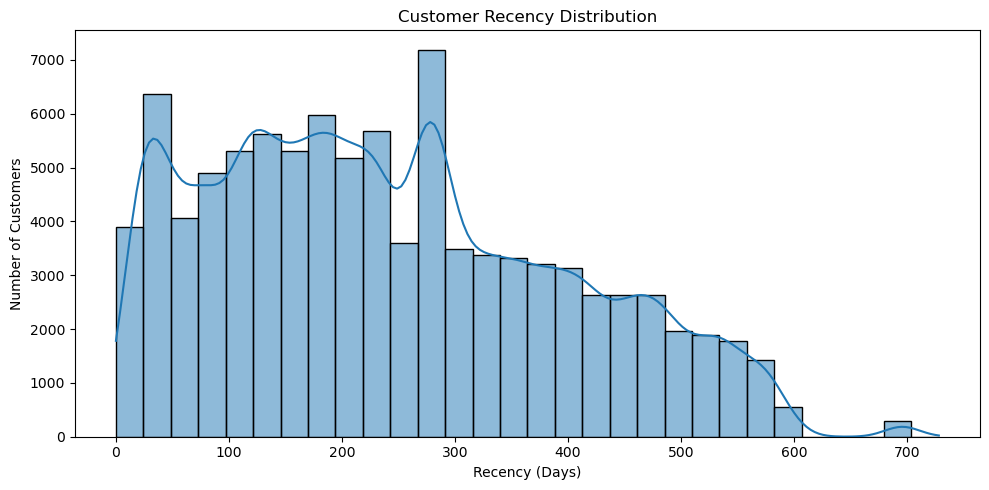

In [25]:
# ---------------------------------------------------------
# 10. Recency Distribution
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    data=customer_summary,
    x='RecencyDays',
    bins=30,
    kde=True
)

plt.title('Customer Recency Distribution')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

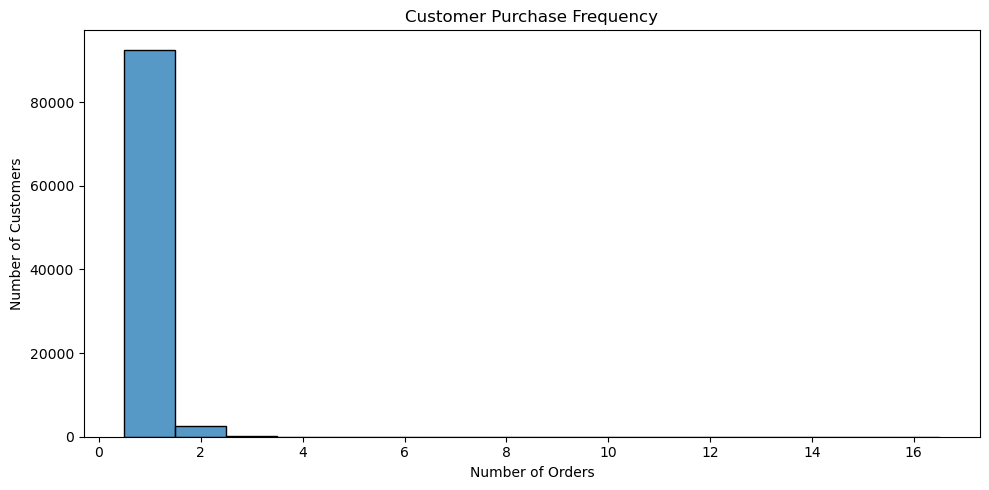

In [29]:
# ---------------------------------------------------------
# 11. Frequency Distribution
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    data=customer_summary,
    x='Frequency',
    discrete=True
)

plt.title('Customer Purchase Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

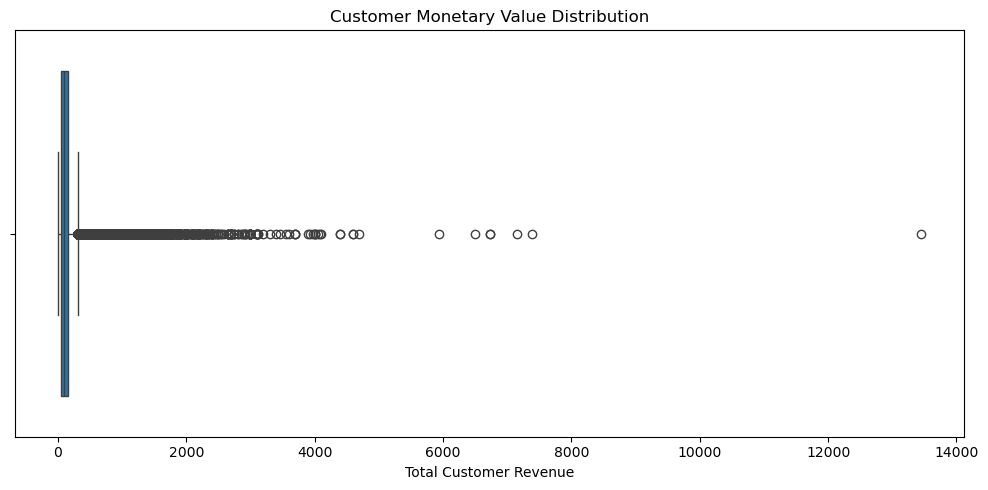

In [30]:
# ---------------------------------------------------------
# 12. Monetary Value Distribution
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=customer_summary,
    x='MonetaryValue'
)

plt.title('Customer Monetary Value Distribution')
plt.xlabel('Total Customer Revenue')

plt.tight_layout()
plt.show()

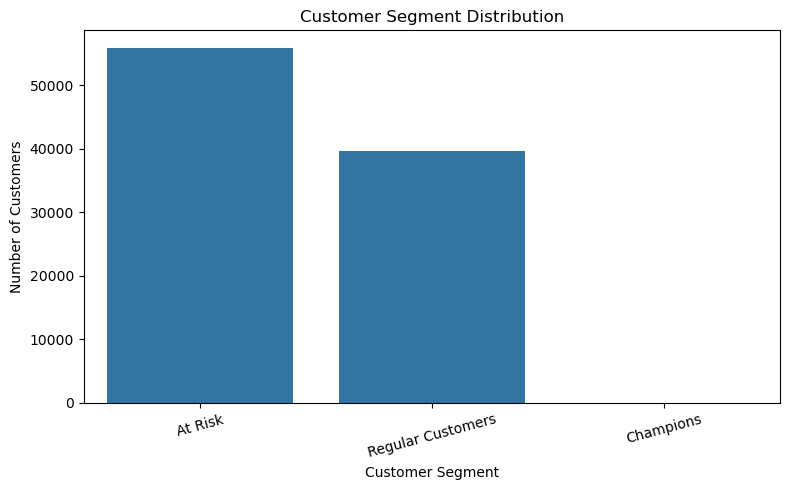

In [31]:
# ---------------------------------------------------------
# 13. Customer Segment Count
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_summary,
    x='CustomerSegment',
    y='TotalCustomers'
)

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [26]:
# ---------------------------------------------------------
# 14. Top Customers by Monetary Value
# ---------------------------------------------------------

top_customers = (
    customer_summary
    .sort_values(
        'MonetaryValue',
        ascending=False
    )
    .head(10)
)

top_customers

,customer_unique_id,LastPurchaseDate,RecencyDays,Frequency,MonetaryValue,CustomerSegment
3799,0a0a92112bd4c708ca5fde585afaa872,2017-09-29 15:24:52,338,1,13440.0,At Risk
81388,da122df9eeddfedc1dc1f5349a1a690c,2017-04-01 15:58:41,519,2,7388.0,Regular Customers
44139,763c8b1c9c68a0229c42c9fc6f662b93,2018-07-15 14:49:44,49,1,7160.0,Regular Customers
82230,dc4802a71eae9be1dd28f5d788ceb526,2017-02-12 20:37:36,567,1,6735.0,At Risk
26015,459bef486812aa25204be022145caa62,2018-07-25 18:10:17,39,1,6729.0,Regular Customers
95131,ff4159b92c40ebe40454e3e6a7c35ed6,2017-05-24 18:14:34,466,1,6499.0,At Risk
23947,4007669dec559734d6f53e029e360987,2017-11-24 11:03:35,282,1,5934.6,At Risk
89056,eebb5dda148d3893cdaf5b5ca3040ccb,2017-04-18 18:50:13,502,1,4690.0,At Risk
34820,5d0a2980b292d049061542014e8960bf,2018-07-12 12:08:36,52,1,4599.9,Regular Customers
27242,48e1ac109decbb87765a3eade6854098,2018-06-22 12:23:19,72,1,4590.0,Regular Customers


In [27]:
# ---------------------------------------------------------
# 15. RFM Summary Statistics
# ---------------------------------------------------------

rfm_summary = pd.DataFrame({
    'Metric': [
        'Total Customers',
        'Average Recency Days',
        'Average Frequency',
        'Average Monetary Value',
        'Maximum Monetary Value'
    ],

    'Value': [
        len(customer_summary),
        round(customer_summary['RecencyDays'].mean(), 2),
        round(customer_summary['Frequency'].mean(), 2),
        round(customer_summary['MonetaryValue'].mean(), 2),
        round(customer_summary['MonetaryValue'].max(), 2)
    ]
})

rfm_summary

,Metric,Value
0,Total Customers,95420.00
1,Average Recency Days,242.60
2,Average Frequency,1.03
3,Average Monetary Value,142.44
4,Maximum Monetary Value,13440.00


In [ ]:
## RFM Customer Insights

The RFM analysis groups customers according to how recently they purchased, how frequently they purchase, and how much revenue they generate. Champions represent customers with recent purchases, higher order frequency, and higher spending. At-risk customers show lower recent activity and limited purchase frequency, making them potential targets for retention campaigns. Regular customers form the remaining customer base and may have opportunities to move into higher-value segments.

In [28]:
# =========================================================
# P16: RFM Segment Revenue Analysis
# =========================================================

# 1. Recreate customer-level RFM data

customer_summary = (
    customer_data
    .groupby('customer_unique_id')
    .agg(
        LastPurchaseDate=(
            'order_purchase_timestamp',
            'max'
        ),
        Frequency=(
            'order_id',
            'nunique'
        ),
        MonetaryValue=(
            'price',
            'sum'
        )
    )
    .reset_index()
)

# 2. Dataset reference date

dataset_max_date = (
    customer_data['order_purchase_timestamp'].max()
)

# 3. Calculate recency

customer_summary['RecencyDays'] = (
    dataset_max_date
    - customer_summary['LastPurchaseDate']
).dt.days

# 4. Create customer segments

customer_summary['CustomerSegment'] = np.select(
    [
        (
            (customer_summary['RecencyDays'] <= 90) &
            (customer_summary['Frequency'] >= 3) &
            (customer_summary['MonetaryValue'] >= 500)
        ),

        (
            (customer_summary['RecencyDays'] > 180) &
            (customer_summary['Frequency'] == 1)
        )
    ],
    [
        'Champions',
        'At Risk'
    ],
    default='Regular Customers'
)

# Check the columns
print(customer_summary.columns.tolist())

['customer_unique_id', 'LastPurchaseDate', 'Frequency', 'MonetaryValue', 'RecencyDays', 'CustomerSegment']


In [29]:
# 5. Segment-level summary

segment_summary = (
    customer_summary
    .groupby('CustomerSegment')
    .agg(
        TotalCustomers=(
            'customer_unique_id',
            'nunique'
        ),
        TotalOrders=(
            'Frequency',
            'sum'
        ),
        TotalRevenue=(
            'MonetaryValue',
            'sum'
        )
    )
    .reset_index()
)

# 6. Calculate averages

segment_summary['AverageRevenuePerCustomer'] = (
    segment_summary['TotalRevenue']
    / segment_summary['TotalCustomers']
)

segment_summary['AverageOrdersPerCustomer'] = (
    segment_summary['TotalOrders']
    / segment_summary['TotalCustomers']
)

# 7. Revenue share

total_revenue = segment_summary['TotalRevenue'].sum()

segment_summary['RevenueSharePercent'] = (
    segment_summary['TotalRevenue'] * 100
    / total_revenue
)

# 8. Round values

segment_summary = segment_summary.round({
    'TotalRevenue': 2,
    'AverageRevenuePerCustomer': 2,
    'AverageOrdersPerCustomer': 2,
    'RevenueSharePercent': 2
})

# 9. Sort by revenue contribution

segment_summary = segment_summary.sort_values(
    'RevenueSharePercent',
    ascending=False
)

segment_summary

,CustomerSegment,TotalCustomers,TotalOrders,TotalRevenue,AverageRevenuePerCustomer,AverageOrdersPerCustomer,RevenueSharePercent
0,At Risk,55823,55823,7652576.59,137.09,1.00,56.30
2,Regular Customers,39578,42757,5918949.83,149.55,1.08,43.55
1,Champions,19,86,20117.28,1058.80,4.53,0.15


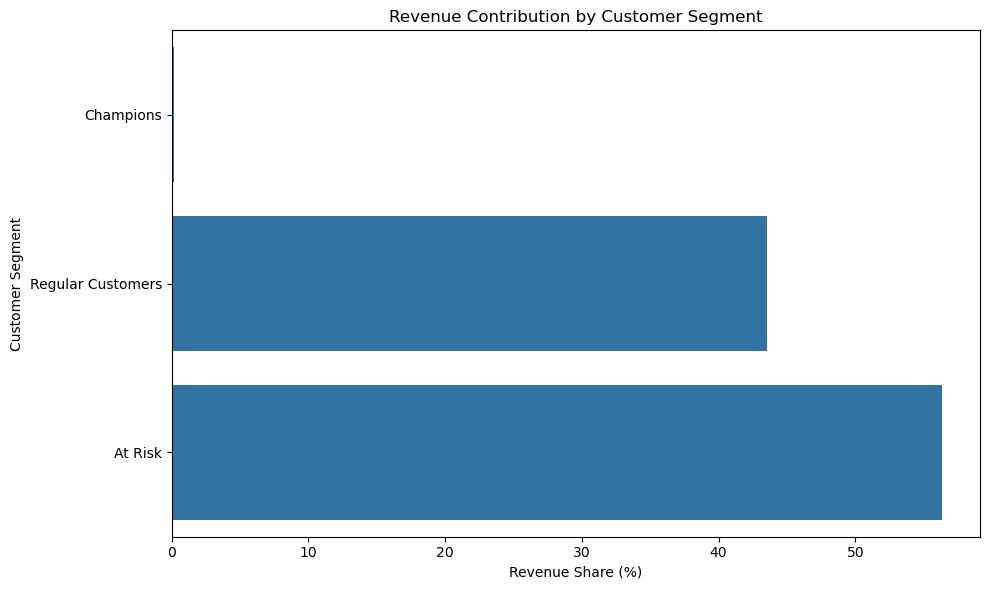

In [30]:
# =========================================================
# Revenue Contribution by Customer Segment
# =========================================================

plot_data = (
    segment_summary
    .sort_values(
        'RevenueSharePercent',
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x='RevenueSharePercent',
    y='CustomerSegment'
)

plt.title('Revenue Contribution by Customer Segment')
plt.xlabel('Revenue Share (%)')
plt.ylabel('Customer Segment')

plt.tight_layout()
plt.show()

In [ ]:
## RFM Segment Insights

The RFM analysis shows how customer value is distributed across the different customer segments. 
The Champions segment represents the customers with the strongest combination of recent purchases,
higher order frequency, and higher spending. Regular Customers may represent the largest portion of 
the customer base, but their revenue contribution should be compared with the Champions segment to 
understand where the highest-value customers are concentrated. The At Risk segment should be monitored
because these customers may have previously purchased but have not returned recently. Retention campaigns, 
personalized offers, and re-engagement strategies could help move At Risk customers toward more valuable segments.

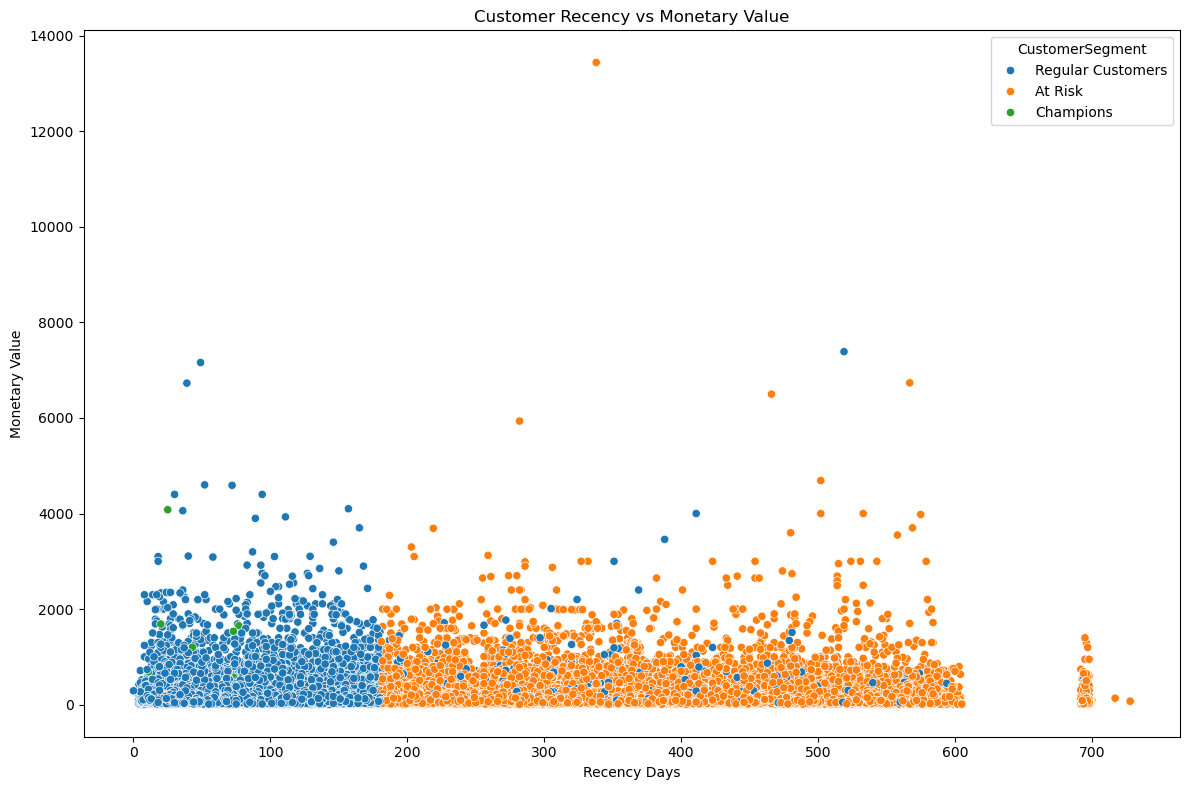

In [31]:
# =========================================================
# P17: Customer Recency vs Monetary Value
# =========================================================

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=customer_summary,
    x='RecencyDays',
    y='MonetaryValue',
    hue='CustomerSegment'
)

plt.title('Customer Recency vs Monetary Value')
plt.xlabel('Recency Days')
plt.ylabel('Monetary Value')

plt.tight_layout()
plt.show()
    

In [55]:
# Correlation between recency and monetary value

correlation = (
    customer_summary[
        ['RecencyDays', 'MonetaryValue']
    ]
    .corr()
)

correlation

,RecencyDays,MonetaryValue
RecencyDays,1.000000,0.000853
MonetaryValue,0.000853,1.000000


In [32]:
recency_monetary_correlation = (
    customer_summary['RecencyDays']
    .corr(customer_summary['MonetaryValue'])
)

print(
    'Recency vs Monetary Value Correlation:',
    round(recency_monetary_correlation, 3)
)

Recency vs Monetary Value Correlation: 0.001


In [33]:
excel_customer_data = segment_summary[
    [
        'CustomerSegment',
        'TotalCustomers',
        'TotalOrders',
        'TotalRevenue',
        'AverageRevenuePerCustomer',
        'AverageOrdersPerCustomer',
        'RevenueSharePercent'
    ]
]

excel_customer_data

,CustomerSegment,TotalCustomers,TotalOrders,TotalRevenue,AverageRevenuePerCustomer,AverageOrdersPerCustomer,RevenueSharePercent
0,At Risk,55823,55823,7652576.59,137.09,1.00,56.30
2,Regular Customers,39578,42757,5918949.83,149.55,1.08,43.55
1,Champions,19,86,20117.28,1058.80,4.53,0.15


In [28]:
excel_customer_data.to_clipboard(index=False)

In [35]:
customer_summary.columns

Index(['customer_unique_id', 'LastPurchaseDate', 'Frequency', 'MonetaryValue',
       'RecencyDays', 'CustomerSegment'],
      dtype='object')

In [39]:
import os

os.makedirs(
    "data/processed/dimension",
    exist_ok=True
)

customer_segment_data = customer_summary[
    [
        "customer_unique_id",
        "RecencyDays",
        "Frequency",
        "MonetaryValue",
        "CustomerSegment"
    ]
]

customer_segment_data.to_csv(
    "data/processed/dimension/DimCustomerSegments.csv",
    index=False
)

In [40]:
customer_segment_data = customer_summary[
    [
        "customer_unique_id",
        "RecencyDays",
        "Frequency",
        "MonetaryValue",
        "CustomerSegment"
    ]
]

customer_segment_data.to_csv(
    r"C:\Users\Lenovo\Desktop\Mahak Project\Ecommerce-Sales-Profit-Analytics\data\processed\dimension\DimCustomerSegments.csv",
    index=False
)

In [41]:
import os

path = r"C:\Users\Lenovo\Desktop\Mahak Project\Ecommerce-Sales-Profit-Analytics\data\processed\dimension\DimCustomerSegments.csv"

print(os.path.exists(path))

True
